# Exploratory Data Analysis (EDA)

In [2]:
#IMPORTING LIBRARIES

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

sns.set(style="whitegrid")
plt.rcParams['figure.figsize'] = (10,6)

In [3]:
#LOADING DATA

df = pd.read_csv("cleaned_hotel_booking.csv")
df.head()

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date,arrival_date,total_stay,total_guests
0,Resort Hotel,0,342,2015,7,27,1,0,0,2,...,0,Transient,0.0,0,0,Check-Out,01-07-2015,2015-07-01,0,2.0
1,Resort Hotel,0,737,2015,7,27,1,0,0,2,...,0,Transient,0.0,0,0,Check-Out,01-07-2015,2015-07-01,0,2.0
2,Resort Hotel,0,7,2015,7,27,1,0,1,1,...,0,Transient,75.0,0,0,Check-Out,02-07-2015,2015-07-01,1,1.0
3,Resort Hotel,0,13,2015,7,27,1,0,1,1,...,0,Transient,75.0,0,0,Check-Out,02-07-2015,2015-07-01,1,1.0
4,Resort Hotel,0,14,2015,7,27,1,0,2,2,...,0,Transient,98.0,0,1,Check-Out,03-07-2015,2015-07-01,2,2.0


In [4]:
print(df.shape)
print(df.info())

(87228, 35)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 87228 entries, 0 to 87227
Data columns (total 35 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   hotel                           87228 non-null  object 
 1   is_canceled                     87228 non-null  int64  
 2   lead_time                       87228 non-null  int64  
 3   arrival_date_year               87228 non-null  int64  
 4   arrival_date_month              87228 non-null  int64  
 5   arrival_date_week_number        87228 non-null  int64  
 6   arrival_date_day_of_month       87228 non-null  int64  
 7   stays_in_weekend_nights         87228 non-null  int64  
 8   stays_in_week_nights            87228 non-null  int64  
 9   adults                          87228 non-null  int64  
 10  children                        87228 non-null  float64
 11  babies                          87228 non-null  int64  
 12  meal                

#1. Cancellation Distribution

Cancellation Rate: 0.27523272343742833


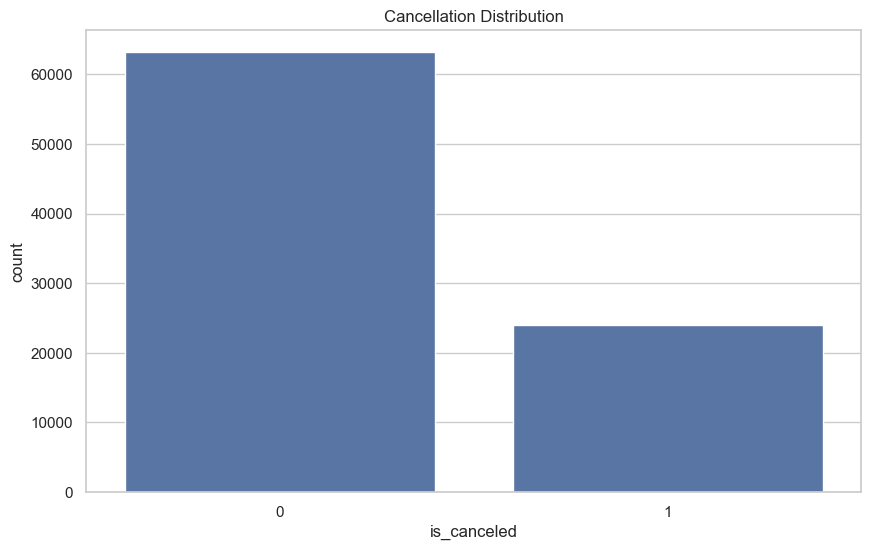

In [5]:
print("Cancellation Rate:", df['is_canceled'].mean())
sns.countplot(x='is_canceled', data=df)
plt.title("Cancellation Distribution")
plt.show()

#2. Lead Time vs Cancellation

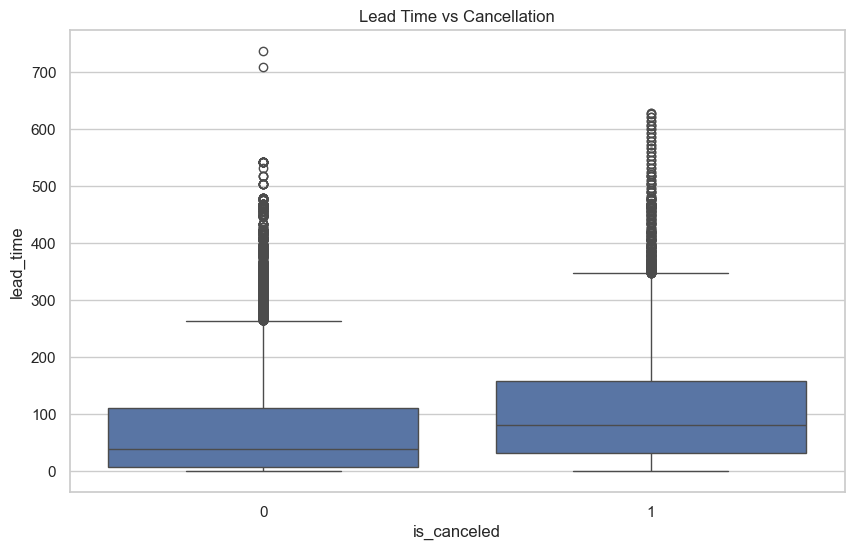

is_canceled
0     70.183581
1    105.741253
Name: lead_time, dtype: float64


In [6]:
sns.boxplot(x='is_canceled', y='lead_time', data=df)
plt.title("Lead Time vs Cancellation")
plt.show()
print(df.groupby('is_canceled')['lead_time'].mean())

#3. Booking Curve (Lead Time vs Bookings)

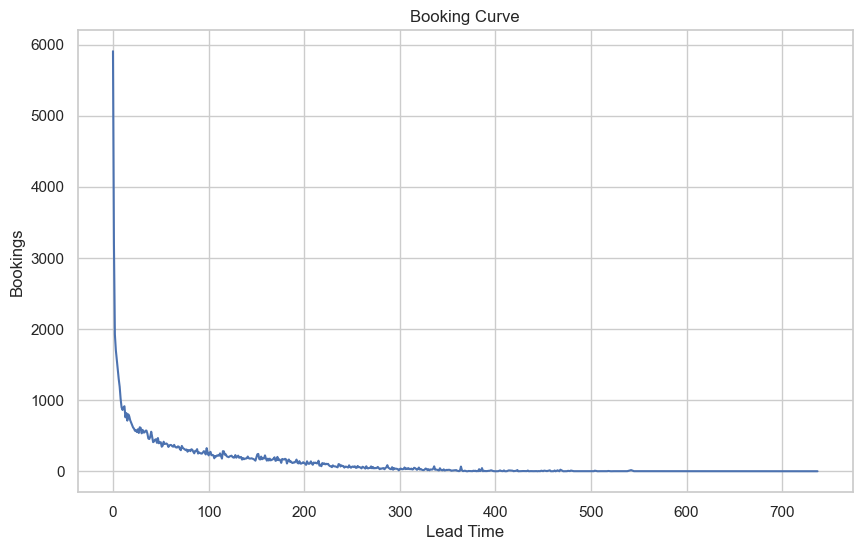

In [7]:
lead_booking = df.groupby('lead_time').size()
lead_booking.plot()
plt.title("Booking Curve")
plt.xlabel("Lead Time")
plt.ylabel("Bookings")
plt.show()

#4. Hotel Type vs Cancellation

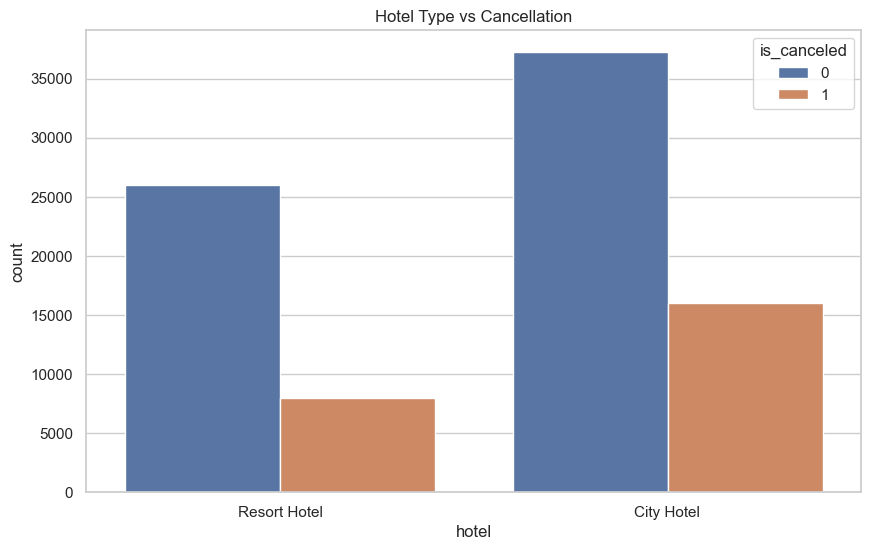

hotel
City Hotel      0.300978
Resort Hotel    0.234840
Name: is_canceled, dtype: float64


In [8]:
sns.countplot(x='hotel', hue='is_canceled', data=df)
plt.title("Hotel Type vs Cancellation")
plt.show()
print(df.groupby('hotel')['is_canceled'].mean())

#5. ADR Analysis

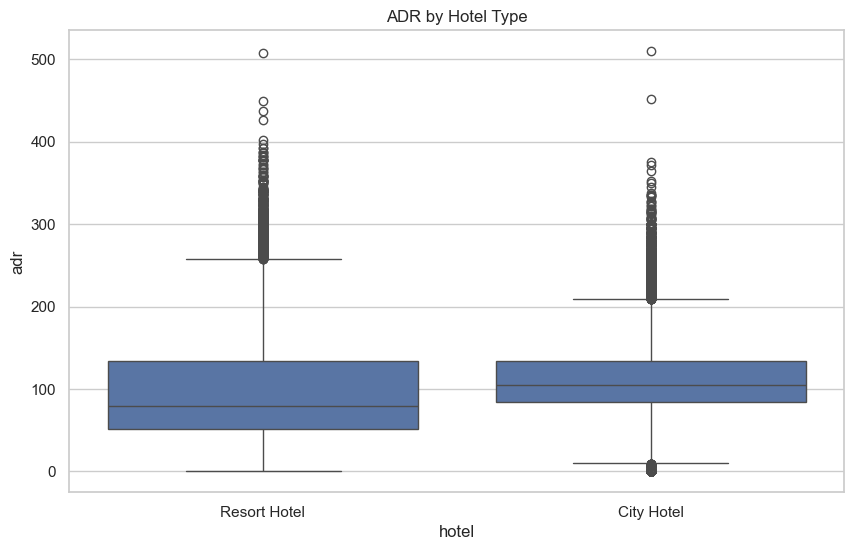

hotel
City Hotel      111.172693
Resort Hotel     99.062622
Name: adr, dtype: float64


In [9]:
sns.boxplot(x='hotel', y='adr', data=df)
plt.title("ADR by Hotel Type")
plt.show()
print(df.groupby('hotel')['adr'].mean())

#6. ADR vs Cancellation

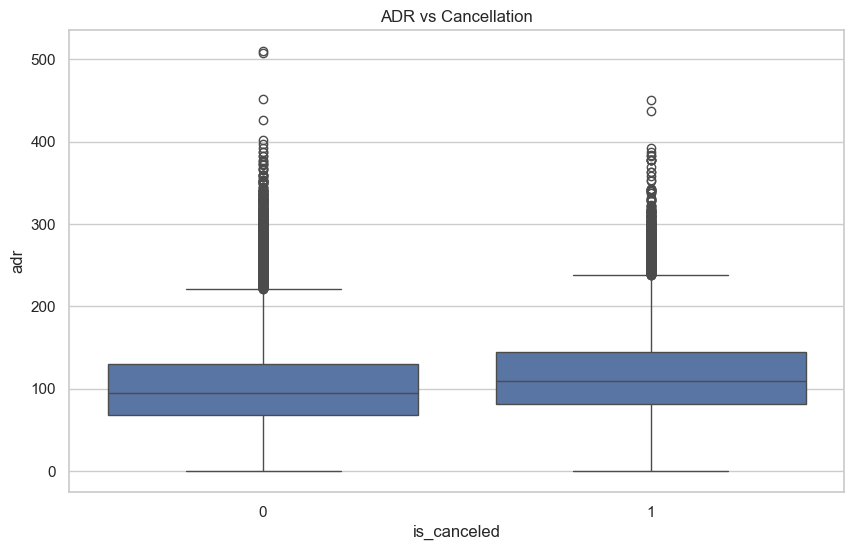

is_canceled
0    102.215920
1    117.630946
Name: adr, dtype: float64


In [10]:
sns.boxplot(x='is_canceled', y='adr', data=df)
plt.title("ADR vs Cancellation")
plt.show()
print(df.groupby('is_canceled')['adr'].mean())

#7. Monthly Booking Trends

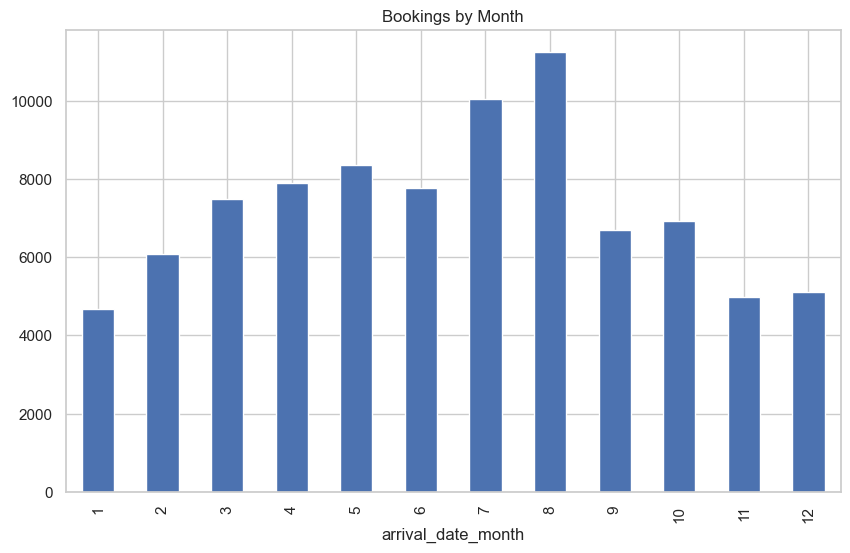

In [11]:
monthly_bookings = df.groupby('arrival_date_month').size()
monthly_bookings.plot(kind='bar')
plt.title("Bookings by Month")
plt.show()

#8. Cancellation Rate by Month

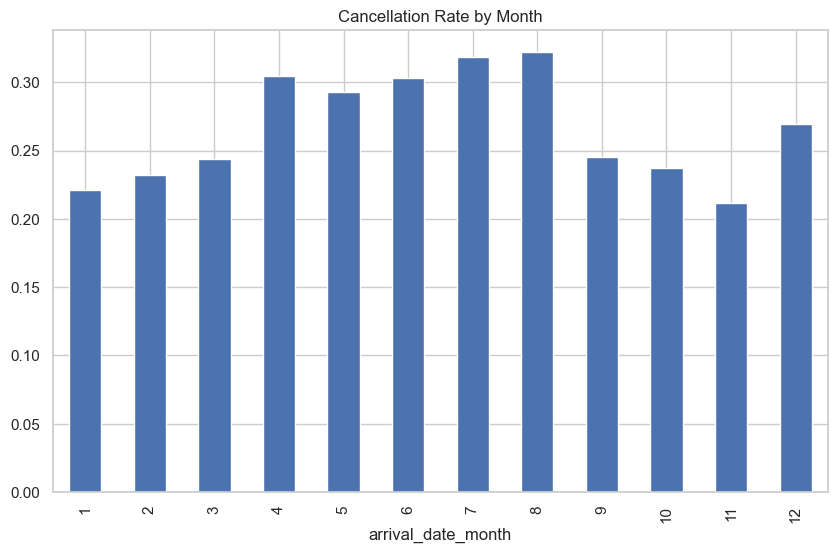

In [12]:
monthly_cancel = df.groupby('arrival_date_month')['is_canceled'].mean()
monthly_cancel.plot(kind='bar')
plt.title("Cancellation Rate by Month")
plt.show()

#9. Market Segment Analysis

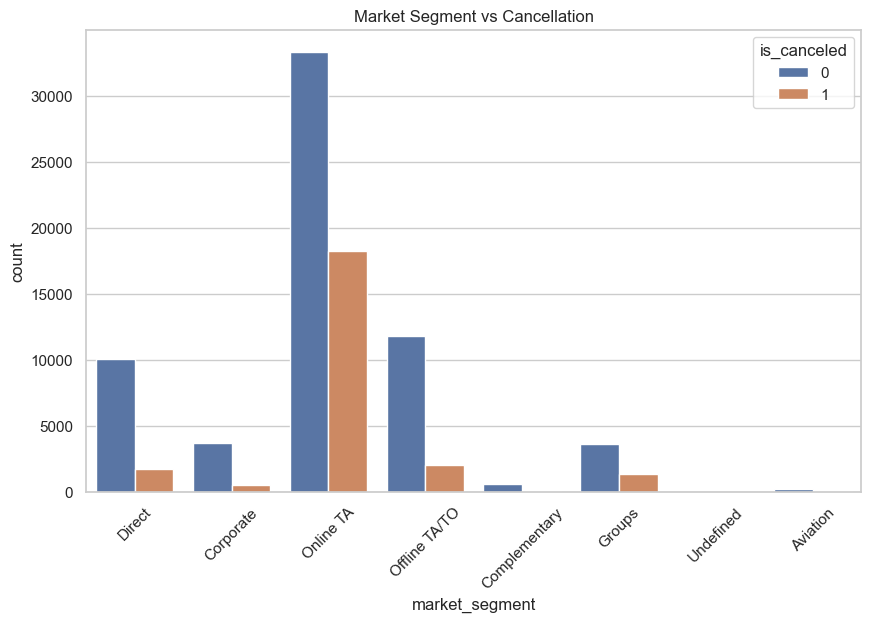

market_segment
Aviation         0.199115
Complementary    0.122832
Corporate        0.121190
Direct           0.147453
Groups           0.270677
Offline TA/TO    0.148405
Online TA        0.353849
Undefined        1.000000
Name: is_canceled, dtype: float64


In [13]:
sns.countplot(x='market_segment', hue='is_canceled', data=df)
plt.xticks(rotation=45)
plt.title("Market Segment vs Cancellation")
plt.show()
print(df.groupby('market_segment')['is_canceled'].mean())

#10. Segment vs Hotel

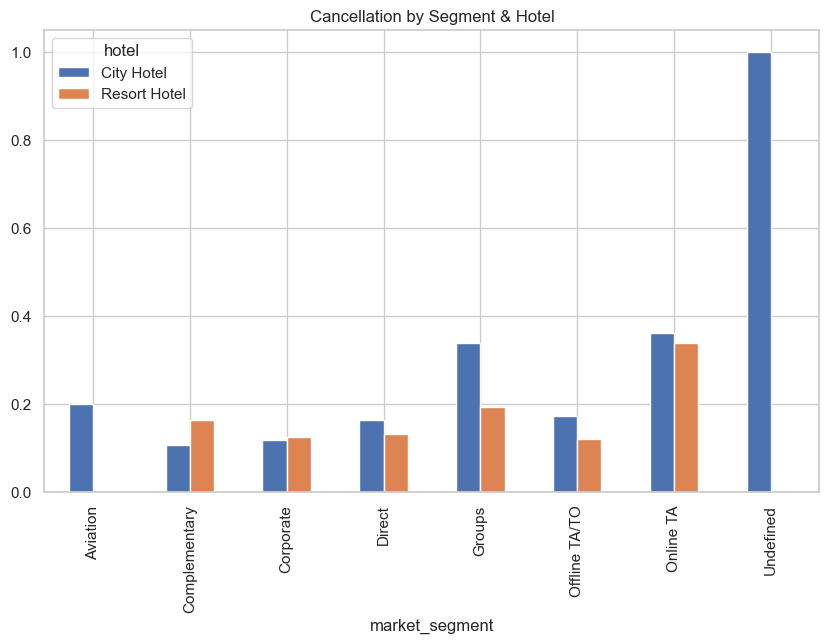

In [14]:
segment = df.groupby(['market_segment', 'hotel'])['is_canceled'].mean().unstack()
segment.plot(kind='bar')
plt.title("Cancellation by Segment & Hotel")
plt.show()

#11. Deposit Type Impact

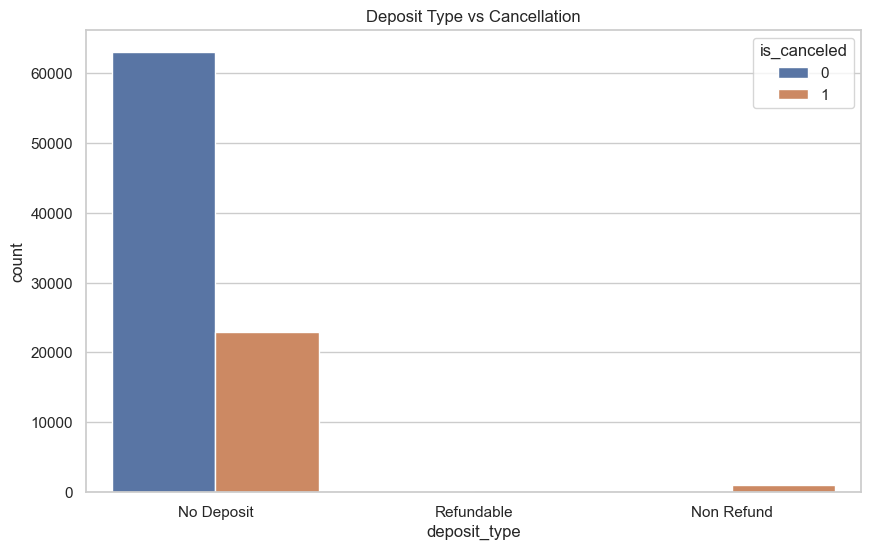

deposit_type
No Deposit    0.267181
Non Refund    0.946962
Refundable    0.242991
Name: is_canceled, dtype: float64


In [15]:
sns.countplot(x='deposit_type', hue='is_canceled', data=df)
plt.title("Deposit Type vs Cancellation")
plt.show()
print(df.groupby('deposit_type')['is_canceled'].mean())

#12. Customer Type

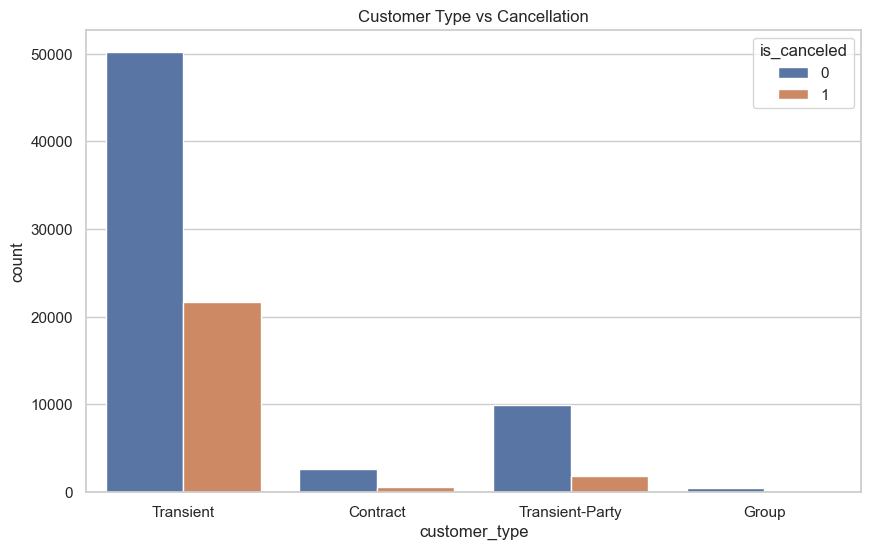

customer_type
Contract           0.163317
Group              0.097967
Transient          0.301415
Transient-Party    0.152510
Name: is_canceled, dtype: float64


In [16]:
sns.countplot(x='customer_type', hue='is_canceled', data=df)
plt.title("Customer Type vs Cancellation")
plt.show()
print(df.groupby('customer_type')['is_canceled'].mean())